<a href="https://colab.research.google.com/github/hjfuentes/UCH_FCFM/blob/main/DMAvanzado%20/M01_MatEst/Dia03_EjemploSwath_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

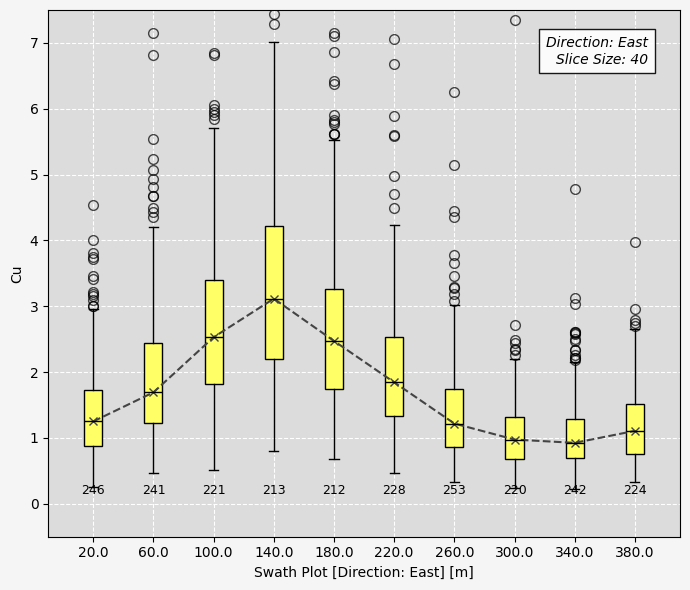

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Crear datos ficticios para el ejemplo
np.random.seed(42)
n_muestras = 2300
easting = np.random.uniform(0, 400, n_muestras)
# Simular leyes de Cobre (Cu) con mayor concentración al centro
cu = np.random.lognormal(mean=0, sigma=0.5, size=n_muestras) * (1 + 2 * np.exp(-((easting - 140) / 80) ** 2))

df = pd.DataFrame({'East': easting, 'Cu': cu})

# 2. Configurar los intervalos (Slice Size: 40)
tamano_slice = 40
bins = np.arange(0, 440, tamano_slice)
df['intervalo'] = pd.cut(df['East'], bins=bins)

# Calcular centros de los intervalos y cantidad de muestras
centros = bins[:-1] + tamano_slice / 2
conteos = df['intervalo'].value_counts().sort_index().values

# Agrupar los datos de Cu por intervalo
datos_agrupados = [df[df['intervalo'] == b]['Cu'].dropna().values for b in df['intervalo'].cat.categories]

# 3. Configurar el diseño del gráfico (Estilo Técnico)
fig, ax = plt.subplots(figsize=(7, 6), facecolor='#f5f5f5')
ax.set_facecolor('#dcdcdc')
ax.grid(True, color='white', linestyle='--', linewidth=0.8)

# 4. Dibujar los Boxplots
bp = ax.boxplot(datos_agrupados, positions=centros, widths=12, patch_artist=True, showfliers=True)

# Estilizar cajas (Amarillas, bordes negros, outliers grandes)
for box in bp['boxes']:
    box.set(facecolor='#ffff66', edgecolor='black', linewidth=1)
for whisker in bp['whiskers']:
    whisker.set(color='black', linestyle='-', linewidth=1)
for flier in bp['fliers']:
    flier.set(marker='o', color='black', markeredgecolor='black', markersize=7, alpha=0.7)
for median in bp['medians']:
    median.set(color='black', linewidth=1)

# 5. Dibujar línea discontinua que conecta las medianas
medianas = [np.median(g) if len(g) > 0 else np.nan for g in datos_agrupados]
ax.plot(centros, medianas, color='#444444', linestyle='--', linewidth=1.5, marker='x')

# 6. Agregar etiquetas de conteo de muestras en la parte inferior
for centro, conteo in zip(centros, conteos):
    ax.text(centro, 0.1, str(conteo), fontsize=9, color='black', ha='center', va='bottom')

# 7. Textos, límites y leyendas
ax.set_xlabel('Swath Plot [Direction: East] [m]', fontsize=10)
ax.set_ylabel('Cu', fontsize=10)
ax.set_xlim(-10, 410)
ax.set_ylim(-0.5, 7.5)

# Cuadro informativo superior derecho
texto_info = "Direction: East\nSlice Size: 40"
ax.text(0.95, 0.95, texto_info, transform=ax.transAxes, fontsize=10, fontstyle='italic',
        va='top', ha='right', bbox=dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()